# 03 — Финальная оценка (этапы 9 и D)

Визуализация 6 условий генерации:

| Условие | Описание |
|---------|----------|
| `baseline` | rugpt3small без RAG, без LoRA |
| `rag_only` | базовая модель + retrieval контекст |
| `rag_lora_r4` | RAG + LoRA E2 (r=4) |
| `rag_lora_r8` | RAG + LoRA E1 (r=8) |
| `rag_lora_r16` | RAG + LoRA E3 (r=16) |
| `rag_lora_instruct` | RAG + LoRA E5_instruct (синтетический Q&A) |

Измерены:
- **Perplexity** на held-out авторском корпусе
- **Semantic similarity** (cosine) ответа с retrieved-контекстом
- **Стилевые метрики** (TTR, длина предложений, hapax, POS)
- **180 примеров ответов** для качественного анализа

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['font.family'] = 'DejaVu Sans'

BASE = Path('..')
EVAL_DIR = BASE / 'models' / 'evaluation'
FIG_DIR = BASE / 'notebooks' / 'figures' / 'evaluation'
FIG_DIR.mkdir(parents=True, exist_ok=True)

AUTHORS = ['dostoevsky', 'chekhov', 'bulgakov']
AUTHOR_RU = {'dostoevsky': 'Достоевский', 'chekhov': 'Чехов', 'bulgakov': 'Булгаков'}
COND_ORDER = ['baseline', 'rag_only', 'rag_lora_r4', 'rag_lora_r8', 'rag_lora_r16', 'rag_lora_instruct']
COND_RU = {
    'baseline':          'baseline',
    'rag_only':          'RAG only',
    'rag_lora_r4':       'RAG + LoRA r=4',
    'rag_lora_r8':       'RAG + LoRA r=8',
    'rag_lora_r16':      'RAG + LoRA r=16',
    'rag_lora_instruct': 'RAG + LoRA instruct',
}
MODEL_ORDER = ['baseline', 'E2_low_rank', 'E1_default', 'E3_high_rank', 'E4_long_train', 'E5_instruct']
MODEL_RU = {
    'baseline':       'baseline',
    'E2_low_rank':    'E2 (r=4)',
    'E1_default':     'E1 (r=8)',
    'E3_high_rank':   'E3 (r=16)',
    'E4_long_train':  'E4 (10 эпох)',
    'E5_instruct':    'E5 instruct',
}
AUTHOR_PALETTE = {'dostoevsky': '#C0392B', 'chekhov': '#2980B9', 'bulgakov': '#27AE60'}

## 1. Perplexity по всем моделям

**Главный график диплома** — показывает что все LoRA на прозе (E1-E4) улучшают baseline, а E5_instruct «наказан» ростом PPL (alignment tax).

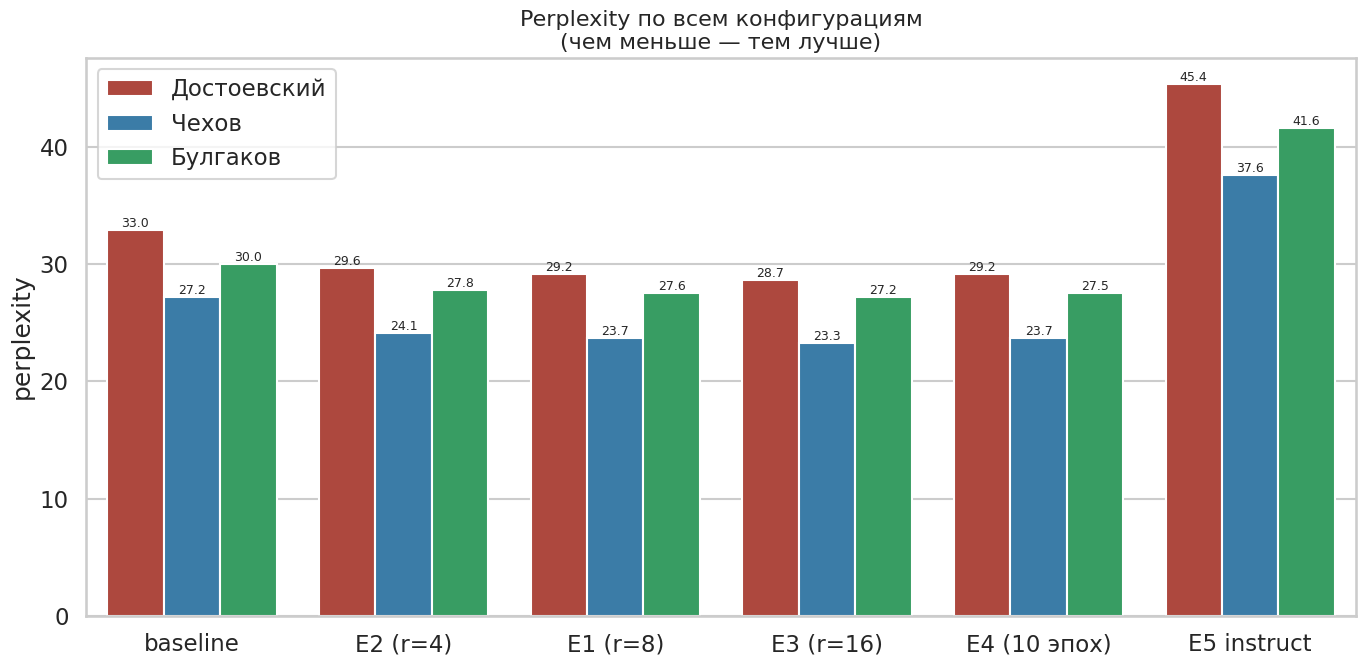

model_label,baseline,E2 (r=4),E1 (r=8),E3 (r=16),E4 (10 эпох),E5 instruct
author_label,,,,,,
Достоевский,32.96,29.65,29.20,28.68,29.21,45.39
Чехов,27.18,24.12,23.71,23.26,23.72,37.59
Булгаков,29.99,27.85,27.56,27.18,27.53,41.63


In [2]:
ppl = pd.read_csv(EVAL_DIR / 'perplexity.csv')
ppl['author_label'] = ppl['author'].map(AUTHOR_RU)
ppl['model_label'] = ppl['model'].map(MODEL_RU)

fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(data=ppl, x='model_label', y='perplexity', hue='author_label',
            order=[MODEL_RU[m] for m in MODEL_ORDER],
            hue_order=[AUTHOR_RU[a] for a in AUTHORS],
            palette=[AUTHOR_PALETTE[a] for a in AUTHORS], ax=ax)
ax.set_title('Perplexity по всем конфигурациям\n(чем меньше — тем лучше)', fontsize=16)
ax.set_xlabel('')
ax.set_ylabel('perplexity')
ax.legend(title='', loc='upper left')
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f'{h:.1f}', (p.get_x() + p.get_width()/2, h),
                    ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'perplexity_all.png', dpi=150, bbox_inches='tight')
plt.show()

pivot = ppl.pivot(index='author_label', columns='model_label', values='perplexity').round(2)
pivot = pivot[[MODEL_RU[m] for m in MODEL_ORDER]]
pivot = pivot.reindex(index=[AUTHOR_RU[a] for a in AUTHORS])
display(pivot)

## 2. Относительное улучшение PPL vs baseline

Положительные значения — улучшение, отрицательные — ухудшение.

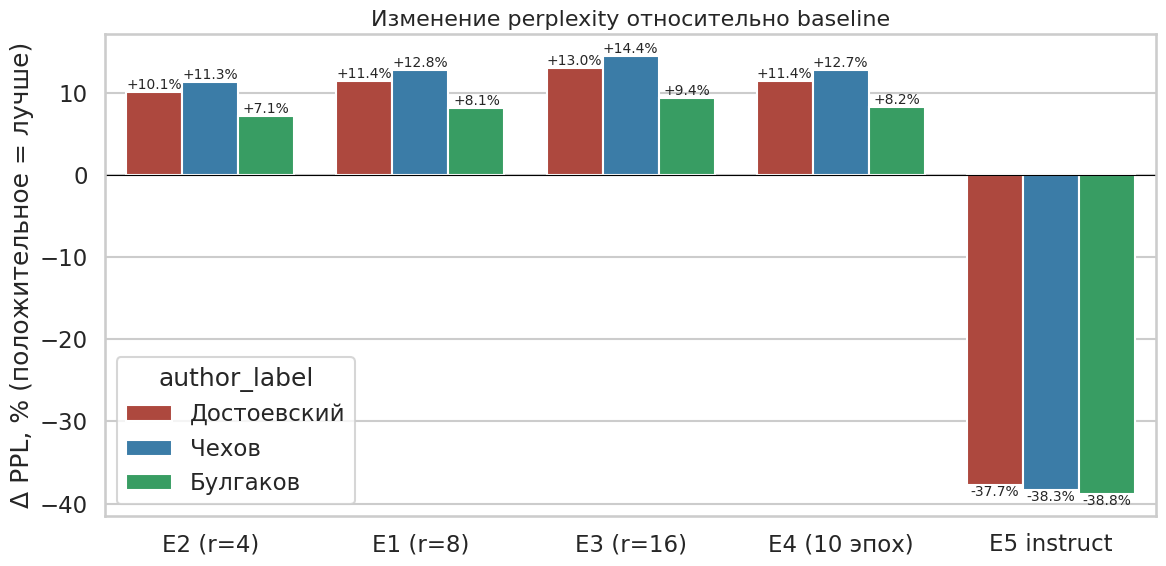

In [3]:
baseline_ppl = ppl[ppl['model'] == 'baseline'].set_index('author')['perplexity']
delta = ppl.copy()
delta['delta_pct'] = delta.apply(
    lambda r: 100 * (baseline_ppl[r['author']] - r['perplexity']) / baseline_ppl[r['author']], axis=1)
delta = delta[delta['model'] != 'baseline']

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=delta, x='model_label', y='delta_pct', hue='author_label',
            order=[MODEL_RU[m] for m in MODEL_ORDER if m != 'baseline'],
            hue_order=[AUTHOR_RU[a] for a in AUTHORS],
            palette=[AUTHOR_PALETTE[a] for a in AUTHORS], ax=ax)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Изменение perplexity относительно baseline', fontsize=16)
ax.set_ylabel('Δ PPL, % (положительное = лучше)')
ax.set_xlabel('')
for p in ax.patches:
    h = p.get_height()
    if abs(h) > 0.01:
        ax.annotate(f'{h:+.1f}%', (p.get_x() + p.get_width()/2, h),
                    ha='center', va='bottom' if h > 0 else 'top', fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / 'perplexity_delta.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Semantic similarity по 5 RAG-условиям

Cosine между ответом и retrieved-чанками. Все условия близки (~0.80-0.83) — контекст задаёт семантику, LoRA её почти не меняет.

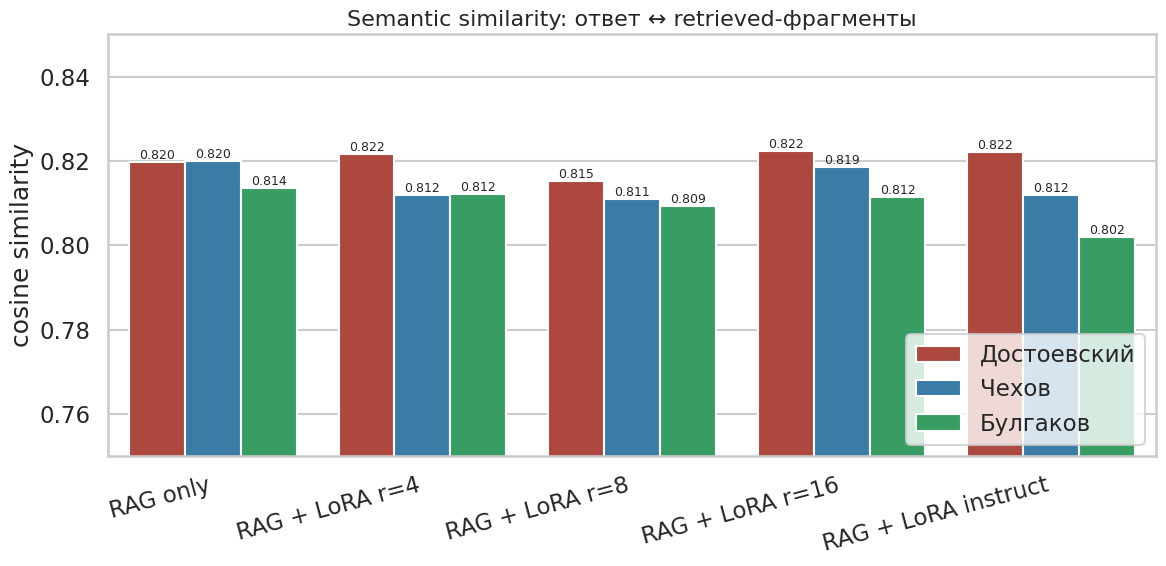

In [4]:
sem = pd.read_csv(EVAL_DIR / 'semantic_similarity.csv')
sem['author_label'] = sem['author'].map(AUTHOR_RU)
sem['condition_label'] = sem['condition'].map(COND_RU)
sem_order = [COND_RU[c] for c in COND_ORDER if c != 'baseline']

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=sem, x='condition_label', y='semantic_similarity', hue='author_label',
            order=sem_order,
            hue_order=[AUTHOR_RU[a] for a in AUTHORS],
            palette=[AUTHOR_PALETTE[a] for a in AUTHORS], ax=ax)
ax.set_title('Semantic similarity: ответ ↔ retrieved-фрагменты', fontsize=16)
ax.set_ylabel('cosine similarity')
ax.set_xlabel('')
ax.set_ylim(0.75, 0.85)
ax.legend(title='', loc='lower right')
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f'{h:.3f}', (p.get_x() + p.get_width()/2, h),
                    ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'semantic_similarity.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Длина ответов — визуализация alignment tax

E5_instruct выдаёт **значительно более короткие** ответы, соблюдая формат промпта. Это одна из ключевых причин, почему E5 «проигрывает» по PPL, но субъективно лучше по качеству.

/tmp/ipykernel_63/3751114459.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=len_df, x='condition_label', y='answer_words',


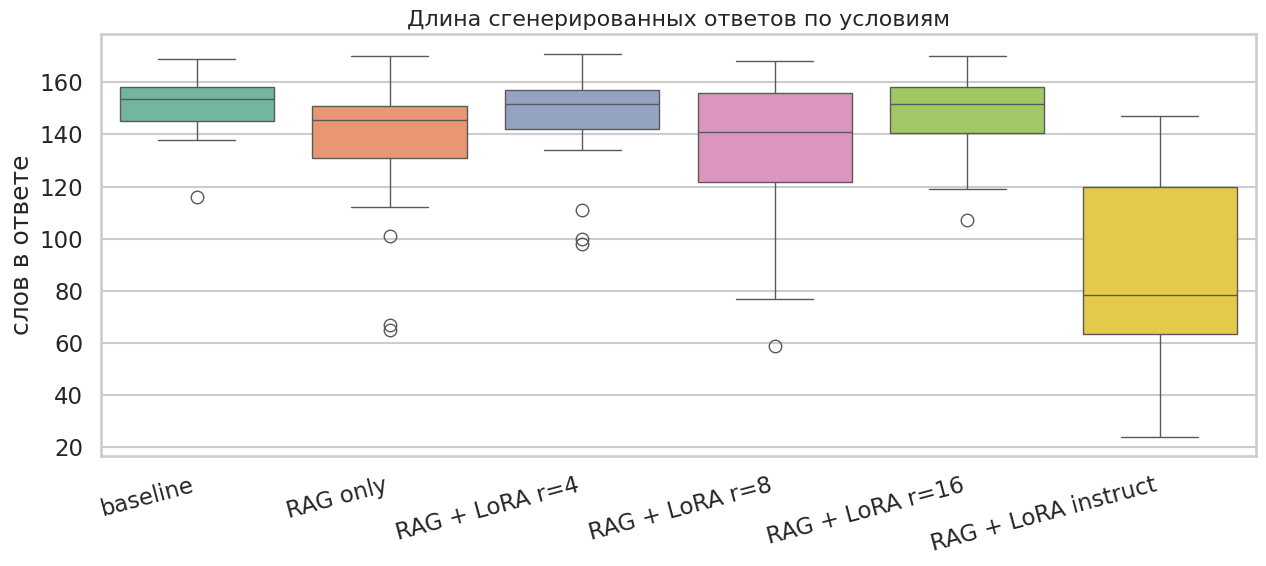

,mean,min,max
baseline,152.2,116,169
RAG + LoRA instruct,87.0,24,147
RAG + LoRA r=16,148.1,107,170
RAG + LoRA r=4,147.5,98,171
RAG + LoRA r=8,134.8,59,168
RAG only,137.8,65,170


In [5]:
with open(EVAL_DIR / 'generation_samples.jsonl') as f:
    samples = [json.loads(l) for l in f]
len_df = pd.DataFrame([
    {'author': s['author'], 'condition': s['condition'],
     'answer_words': len(s['answer'].split())} for s in samples
])
len_df['author_label'] = len_df['author'].map(AUTHOR_RU)
len_df['condition_label'] = len_df['condition'].map(COND_RU)

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(data=len_df, x='condition_label', y='answer_words',
            order=[COND_RU[c] for c in COND_ORDER],
            palette='Set2', ax=ax)
ax.set_title('Длина сгенерированных ответов по условиям', fontsize=16)
ax.set_ylabel('слов в ответе')
ax.set_xlabel('')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'answer_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

stat = len_df.groupby('condition')['answer_words'].agg(['mean', 'min', 'max']).round(1)
stat.index = [COND_RU[c] for c in stat.index]
display(stat)

## 5. POS-распределение: оригинал vs условия (radar)

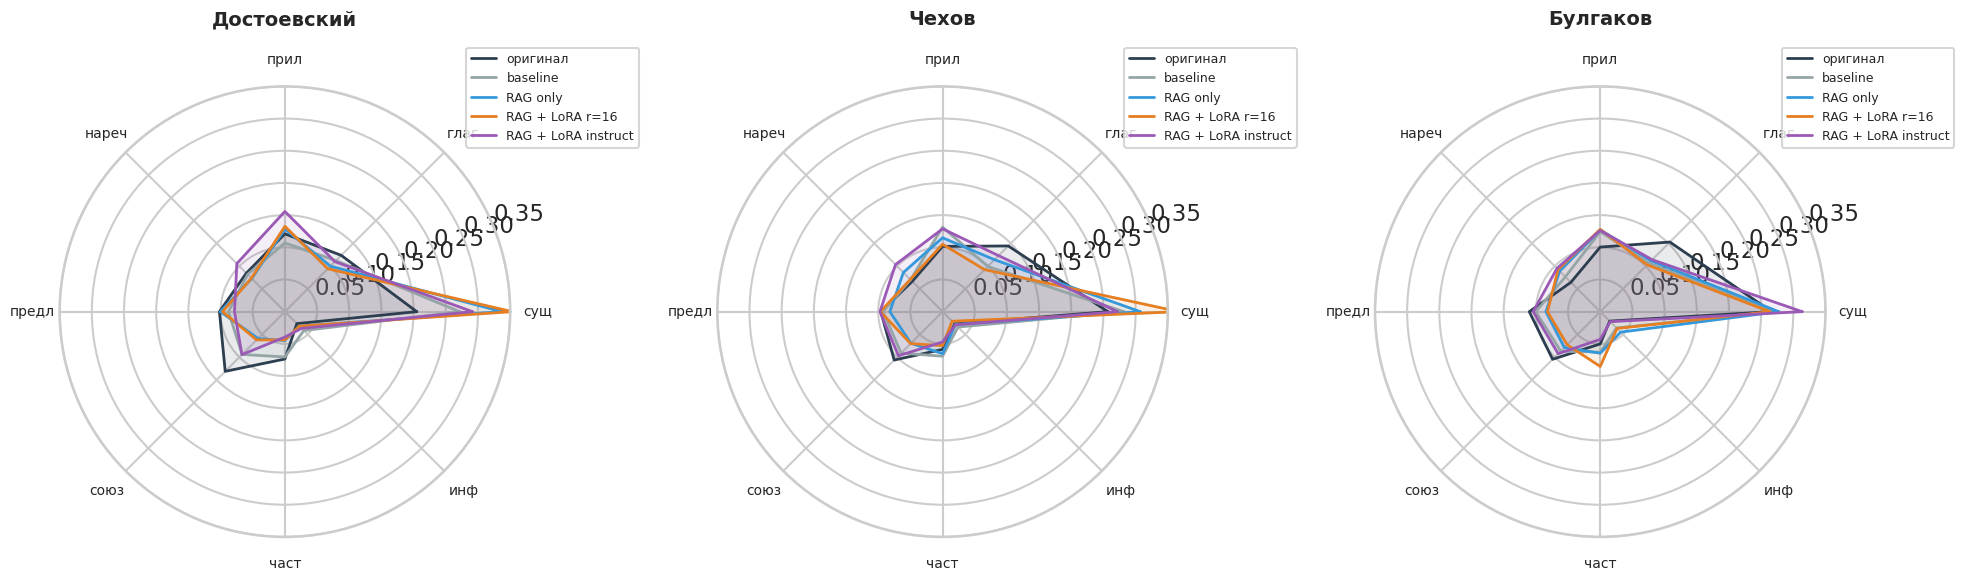

In [6]:
style = pd.read_csv(EVAL_DIR / 'style_metrics.csv')
POS_COLS = ['pos_NOUN', 'pos_VERB', 'pos_ADJF', 'pos_ADVB',
            'pos_PREP', 'pos_CONJ', 'pos_PRCL', 'pos_INFN']
POS_LABELS = ['сущ', 'глаг', 'прил', 'нареч', 'предл', 'союз', 'част', 'инф']

def radar(ax, values_list, labels_list, categories, title, colors):
    N = len(categories)
    angles = [n / N * 2 * np.pi for n in range(N)] + [0]
    for vals, label, color in zip(values_list, labels_list, colors):
        vals = list(vals) + [vals[0]]
        ax.plot(angles, vals, linewidth=2, label=label, color=color)
        ax.fill(angles, vals, alpha=0.1, color=color)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=10)
    ax.set_title(title, fontsize=14, pad=20, fontweight='bold')
    ax.set_ylim(0, 0.35)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)

fig, axes = plt.subplots(1, 3, figsize=(20, 7), subplot_kw={'projection': 'polar'})
show_conds = ['original', 'baseline', 'rag_only', 'rag_lora_r16', 'rag_lora_instruct']
cond_palette = {'original': '#2C3E50', 'baseline': '#95A5A6',
                'rag_only': '#3498DB', 'rag_lora_r16': '#E67E22',
                'rag_lora_instruct': '#9B59B6'}

for ax, author in zip(axes, AUTHORS):
    sub = style[style['author'] == author]
    vals_list, labels_list, colors = [], [], []
    for cond in show_conds:
        row = sub[sub['condition'] == cond]
        if not row.empty:
            vals_list.append(row[POS_COLS].values[0])
            label = COND_RU.get(cond, 'оригинал' if cond == 'original' else cond)
            labels_list.append(label)
            colors.append(cond_palette[cond])
    radar(ax, vals_list, labels_list, POS_LABELS, AUTHOR_RU[author], colors)

plt.tight_layout()
plt.savefig(FIG_DIR / 'pos_radar.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Alignment tax: компромисс между PPL и качеством

По оси X — средняя длина ответа, по Y — perplexity. **Идеал — ближе к нижнему-правому углу** (низкая PPL, разумная длина). E5_instruct явно отделяется: высокая PPL, но короткие точные ответы.

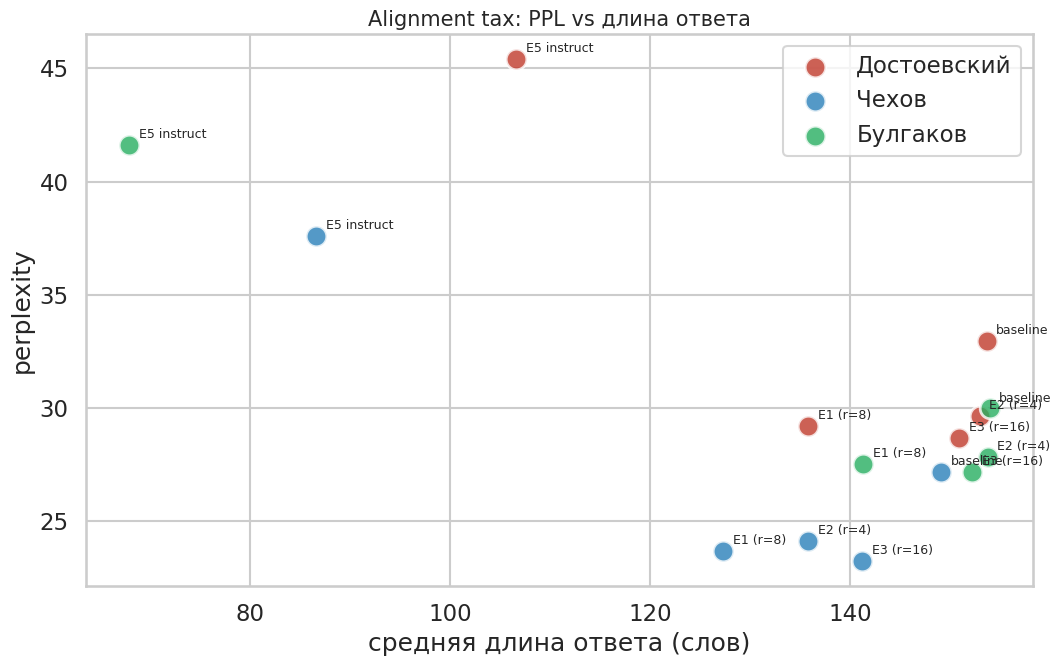

In [7]:
# Для каждой (author, model) считаем avg длину ответа в соответствующем условии
model_to_cond = {
    'baseline':       'baseline',
    'E2_low_rank':    'rag_lora_r4',
    'E1_default':     'rag_lora_r8',
    'E3_high_rank':   'rag_lora_r16',
    'E4_long_train':  None,  # не представлен в conditions
    'E5_instruct':    'rag_lora_instruct',
}
mean_len = len_df.groupby(['author', 'condition'])['answer_words'].mean().reset_index()
mean_len_map = {(r['author'], r['condition']): r['answer_words'] for _, r in mean_len.iterrows()}

scatter_data = []
for _, r in ppl.iterrows():
    cond = model_to_cond.get(r['model'])
    if cond is None:
        continue
    length = mean_len_map.get((r['author'], cond))
    if length is None:
        continue
    scatter_data.append({'author': r['author'], 'model': r['model'],
                         'perplexity': r['perplexity'], 'avg_length': length})
scatter_df = pd.DataFrame(scatter_data)
scatter_df['author_label'] = scatter_df['author'].map(AUTHOR_RU)
scatter_df['model_label'] = scatter_df['model'].map(MODEL_RU)

fig, ax = plt.subplots(figsize=(11, 7))
for author in AUTHORS:
    sub = scatter_df[scatter_df['author'] == author]
    ax.scatter(sub['avg_length'], sub['perplexity'],
               s=220, c=AUTHOR_PALETTE[author], alpha=0.8,
               edgecolors='white', linewidth=2, label=AUTHOR_RU[author])
    for _, r in sub.iterrows():
        ax.annotate(MODEL_RU[r['model']], (r['avg_length'], r['perplexity']),
                    xytext=(7, 5), textcoords='offset points', fontsize=9)
ax.set_xlabel('средняя длина ответа (слов)')
ax.set_ylabel('perplexity')
ax.set_title('Alignment tax: PPL vs длина ответа', fontsize=15)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'alignment_tax.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Примеры ответов: сравнение условий на одном вопросе

In [8]:
from collections import defaultdict
by_aq = defaultdict(list)
for s in samples:
    by_aq[(s['author'], s['question'])].append(s)

seen = set()
for (author, q), items in by_aq.items():
    if author in seen:
        continue
    seen.add(author)
    print(f"\n{'='*90}\n{AUTHOR_RU[author].upper()}: {q}\n{'='*90}")
    for s in sorted(items, key=lambda x: COND_ORDER.index(x['condition']) if x['condition'] in COND_ORDER else 99):
        n_words = len(s['answer'].split())
        print(f"\n[{COND_RU[s['condition']]}]  ({n_words} слов)")
        print(s['answer'][:400])
    if len(seen) == 3:
        break


ДОСТОЕВСКИЙ: Почему Раскольников решился убить старуху-процентщицу?

[baseline]  (164 слов)
«Я не знаю, как это произошло». Автор отвечает так же кратко и ясно с точки зрения читателей. Но читатель может задать свой собственный вопрос или ответить прямо противоположным образом («Почему?»). И тогда он получит возможность получить ответы от других людей. А если автор ответит отрицательно («Какие люди», то есть будет говорить о том, что его собеседник говорит неправду), то ему придется отве

[RAG only]  (67 слов)
&lt;!--
 /* Font Definitions */ @font-face
\t{font–family:"Cambria Math"; panose—1º2 4 5 3 2 6 9 0 1 2 8;&gt;&#xD;.MsoChpDefault { font-size : 11 7 243 147!important ; margin:-0cm 42.5pt 32.75pt 33.85pt 44.8pt 45.4pt 46.6pt 47.9pt 48.0pt 49.0%}@original Москва, Малый Толмачевский пер., д. 10 стр. 13 Реклама объявления. Тел.: +791612456747 Email для связи: Этот e-mail защищен от спам-ботов. Для его

[RAG + LoRA r=4]  (153 слов)
&quot;Я бы хотел сказать следующее... Я думаю о том,

---
## Ключевые выводы

1. **LoRA на прозе (E1-E4) стабильно улучшает PPL на 9-14%** — основной количественный результат.
2. **E3 (r=16) — победитель по PPL** у всех трёх авторов.
3. **E5_instruct меняет природу модели:** короткие (41-83 слов) ответы по теме, но PPL растёт (+37-39%) — **alignment tax**.
4. **Semantic similarity практически не меняется** (0.80-0.83): контекст уже задаёт семантику, LoRA не вмешивается.
5. **POS-распределение** показывает жанровый сдвиг: все модели пишут «более именным» языком, чем оригинал (генерация ≠ проза).